In [ ]:

print("Status:", data.get("cod"))

# Lấy dữ liệu thời tiết


# Tách ngày
df["date"] = df["time"].dt.date
# Gom theo ngày (lấy trung bình)
df_day = df.groupby("date").mean(numeric_only=True)
print(df_day)

Status: 200
            pressure      wind
date                          
2026-04-09  1011.000  2.956667
2026-04-10  1010.125  3.947500
2026-04-11  1008.875  4.250000
2026-04-12  1008.250  4.187500
2026-04-13  1008.625  3.998750
2026-04-14  1008.200  4.006000


In [ ]:
import requests
import pandas as pd
import matplotlib.pyplot as plt

# Thông tin API
api_key = "b72e7baa47c43e19be50ad2fab266d84"
city = "Ho Chi Minh City,vn"
url = f"http://api.openweathermap.org/data/2.5/forecast?q={city}&appid={api_key}&units=metric"

# Gọi API
res = requests.get(url)
data = res.json()

- Ở link api ta cần điền 2 giá trị là tên thành phố và mã api, sau khi có 2 giá trị này ta chỉ cần gửi request tới api 

In [4]:
lst = data["list"]
time = []
pressure = []
wind = []
for i in lst:
    time.append(i["dt_txt"])
    pressure.append(i["main"]["pressure"])
    wind.append(i["wind"]["speed"])

- Sau khi có api, ta cần lấy 3 giá trị chính là thời gian, áp suất và gió 

In [5]:
# Tạo dataframe
df = pd.DataFrame({
    "time": pd.to_datetime(time),
    "pressure": pressure,
    "wind": wind
})

- Sau đó tạo dataframe từ 3 giá trị ta thu được 

In [6]:
df["date"] = df["time"].dt.date
df_day = df.groupby("date").mean(numeric_only=True)

- Giờ ta chỉ cần chuyển định dạng date từ string sang date 
- Tạo 1 dataframe mới nhóm lại các dữ liệu theo ngày rồi tính mean

### a) Vẽ biểu đồ áp suất không khí (pressure) theo từng ngày.

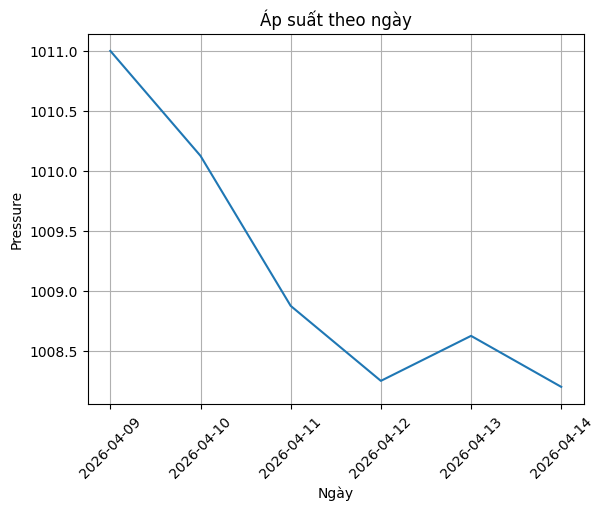

In [8]:
plt.figure()
plt.plot(df_day.index, df_day["pressure"])
plt.title("Áp suất theo ngày")
plt.xlabel("Ngày")
plt.ylabel("Pressure")
plt.xticks(rotation=45)
plt.grid(True)
plt.show()

### b) Vẽ biểu đồ tốc độ gió (wind speed) theo từng ngày.

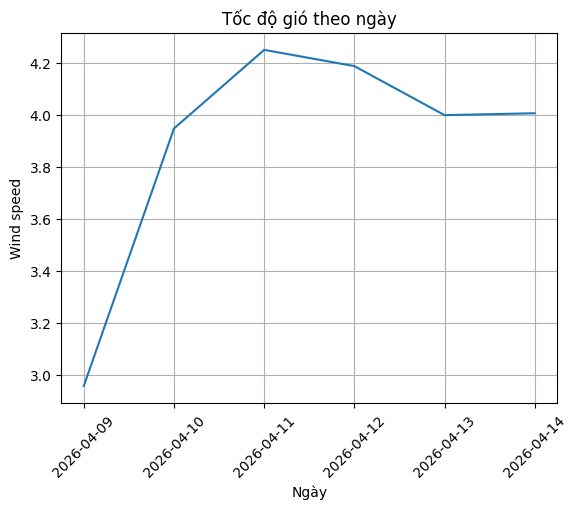

In [9]:
plt.figure()
plt.plot(df_day.index, df_day["wind"])
plt.title("Tốc độ gió theo ngày")
plt.xlabel("Ngày")
plt.ylabel("Wind speed")
plt.xticks(rotation=45)
plt.grid(True)
plt.show()